**CSP=(X,D,C)**

CSP (Constraint Satisfaction Problem) Framework = (variable, domain, constraint)

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

from src.csp import CSP
from src.constraints import BinaryConstraint
from src.solvers import (
    backtracking_search,
    backtracking_search_mrv,
    backtracking_search_mrv_degree,
    backtracking_search_with_stats,
    backtracking_search_mrv_with_stats,
    backtracking_search_mrv_degree_with_stats,
)
from src.generators import (
    generate_graph_coloring_csp
)
from src.experiments import (
    run_solver_experiment
)

<h1> Map Coloring Example </h1>

In [2]:
variables = [
    "WA",
    "NT",
    "SA",
    "Q",
]

colors = [
    "Red",
    "Green",
    "Blue",
]

domains = {
    variable: colors.copy()
    for variable in variables
}

constraints = [

    BinaryConstraint(
        "WA",
        "NT",
    ),

    BinaryConstraint(
        "WA",
        "SA",
    ),

    BinaryConstraint(
        "NT",
        "SA",
    ),

    BinaryConstraint(
        "NT",
        "Q",
    ),

    BinaryConstraint(
        "SA",
        "Q",
    ),
]

neighbors = {

    "WA": [
        "NT",
        "SA",
    ],

    "NT": [
        "WA",
        "SA",
        "Q",
    ],

    "SA": [
        "WA",
        "NT",
        "Q",
    ],

    "Q": [
        "NT",
        "SA",
    ],
}

In [3]:
problem = CSP(
    variables,
    domains,
    constraints,
    neighbors,
)

For this step, we will create the neighbors manually, but a better design is to have CSP itself create this graph later based on the constraints.

In [4]:
problem.validate()

problem.get_domains_copy()

{'WA': ['Red', 'Green', 'Blue'],
 'NT': ['Red', 'Green', 'Blue'],
 'SA': ['Red', 'Green', 'Blue'],
 'Q': ['Red', 'Green', 'Blue']}

In [5]:
assignment = {
    "WA":"Red",
    "NT":"Green",
    "SA":"Blue",
}

In [6]:
problem.is_consistent(
    assignment
)

True

In [7]:
assignment = {
    "WA":"Red",
    "NT":"Red",
}

In [8]:
problem.is_consistent(
    assignment
)

False

Naive Backtracking

In [9]:
solution = backtracking_search(
    problem
)

solution

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

<h1> MRV — Minimum Remaining Values </h1>

Idea:
Choose the variable that has the fewest remaining choices.

In [10]:
solution_basic = backtracking_search(
    problem
)

solution_basic

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

In [11]:
solution_mrv = backtracking_search_mrv(
    problem
)

solution_mrv

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

<h1> Degree Heuristic + MRV Tie Breaking </h1>

Degree Idea 

Choose the variable that:</br>
has the most constraints with other variables.

High impact variable first

**MRV + Degree combination**

Algorithm:

First MRV: Lowest Domain.

If multiple options are equal: Highest Degree.

In [12]:
solution_mrv_degree = backtracking_search_mrv_degree(
    problem
)

solution_mrv_degree

{'NT': 'Red', 'SA': 'Green', 'WA': 'Blue', 'Q': 'Blue'}

In CSP, each Assignment is a Node in the Search Tree.

In [13]:
solution, stats = backtracking_search_with_stats(
    problem
)

solution

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

In [14]:
stats.summary()

{'Nodes Visited': 5, 'Assignments Tried': 7, 'Backtracks': 0}

We still don't see the power of heuristics, so let's build a real benchmark.

<h3> Instrumenting Heuristic Solvers </h3>

Comparing:

Naive Backtracking</br>
vs</br>
MRV Backtracking</br>
vs</br>
MRV + Degree

Metric:

Nodes Visited</br>
Assignments Tried</br>
Backtracks</br>

In [15]:
solution_mrv_stats, stats_mrv = backtracking_search_mrv_with_stats(problem)

solution_mrv_stats

{'WA': 'Red', 'NT': 'Green', 'SA': 'Blue', 'Q': 'Red'}

In [16]:
stats_mrv.summary()

{'Nodes Visited': 5, 'Assignments Tried': 7, 'Backtracks': 0}

Heuristics show their value when the search space is large or the constraints are hard.

In [17]:
solution_mrv_degree_stats, stats_mrv_degree = (
    backtracking_search_mrv_degree_with_stats(
        problem
    )
)

solution_mrv_degree_stats

{'NT': 'Red', 'SA': 'Green', 'WA': 'Blue', 'Q': 'Blue'}

In [18]:
stats_mrv_degree.summary()

{'Nodes Visited': 5, 'Assignments Tried': 9, 'Backtracks': 0}

That is, Degree has an effect on the order of selection, but because the problem is simple, we have not yet entered an area where a real difference can be seen.

In [19]:
random_problem = generate_graph_coloring_csp(
    num_variables=20,
    num_colors=4,
    edge_probability=0.2,
)

random_problem

In [20]:
len(random_problem.variables)

20

In [21]:
len(random_problem.constraints)

41

In [22]:
random_problem.neighbors["X0"]

['X1', 'X2', 'X11', 'X13', 'X15']

<h1> Benchmark Framework </h1>

In [23]:
solvers = [
    (
        "Naive",
        backtracking_search_with_stats
    ),
    (
        "MRV",
        backtracking_search_mrv_with_stats
    ),
    (
        "MRV+Degree",
        backtracking_search_mrv_degree_with_stats
    )
]

In [24]:
problem = generate_graph_coloring_csp(
    num_variables=30,
    num_colors=4,
    edge_probability=0.2,
)

results = []

for name, solver in solvers:

    result = run_solver_experiment(
        problem,
        solver,
    )

    result["Algorithm"] = name

    results.append(result)

In [25]:
benchmark_df = pd.DataFrame(
    results
)

benchmark_df

,Nodes Visited,Assignments Tried,Backtracks,Success,Execution Time,Algorithm
0,1518819,6075226,1518788,True,78.168910,Naive
1,1518819,6075226,1518788,True,84.343621,MRV
2,57,178,26,True,0.002932,MRV+Degree


<h1> Multi Trial Benchmark </h1>

making a loop of trials

In [26]:
all_results = []

trials = 10

for trial in range(trials):
    problem = generate_graph_coloring_csp(
        num_variables=30,
        num_colors=4,
        edge_probability=0.2,
    )

    for name, solver in solvers:
        result = run_solver_experiment(
            problem,
            solver,
        )
        result["Algorithm"] = name
        result["Trial"] = trial
        all_results.append(result)

In [27]:
benchmark_df = pd.DataFrame(
    all_results
)

benchmark_df

,Nodes Visited,Assignments Tried,Backtracks,Success,Execution Time,Algorithm,Trial
0,1842,7311,1811,True,0.098546,Naive,0
1,1842,7311,1811,True,0.096039,MRV,0
2,38,99,7,True,0.001296,MRV+Degree,0
3,10232,40875,10201,True,0.529599,Naive,1
4,10232,40875,10201,True,0.602475,MRV,1
5,37,92,6,True,0.002307,MRV+Degree,1
6,276462,1105792,276431,True,12.726634,Naive,2
7,276462,1105792,276431,True,13.635751,MRV,2
8,123,449,92,True,0.005366,MRV+Degree,2
9,150368,601419,150337,True,6.348615,Naive,3


In [33]:
benchmark_summary = (
    benchmark_df
    .groupby(
        "Algorithm"
    )
    [
        [
            "Nodes Visited",
            "Assignments Tried",
            "Backtracks",
            "Execution Time",
            "Success",
        ]
    ]
    .mean()
    .reset_index()
)

In [34]:
benchmark_summary

,Algorithm,Nodes Visited,Assignments Tried,Backtracks,Execution Time,Success
0,MRV,345027.6,1380054.1,344996.6,17.074768,1.0
1,MRV+Degree,173.7,642.7,142.7,0.008717,1.0
2,Naive,345027.6,1380054.1,344996.6,16.571864,1.0


<AxesSubplot: xlabel='Algorithm'>

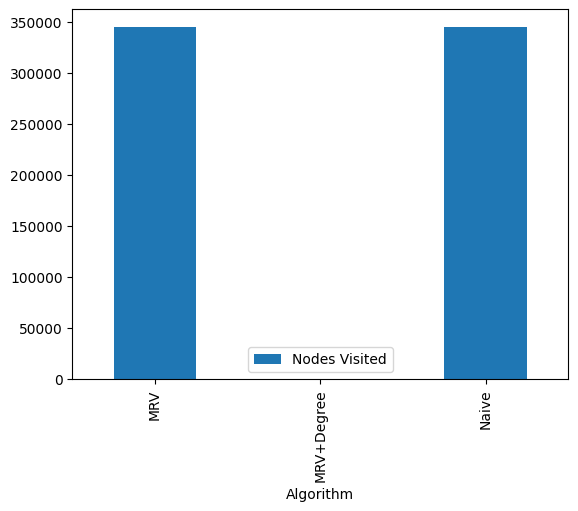

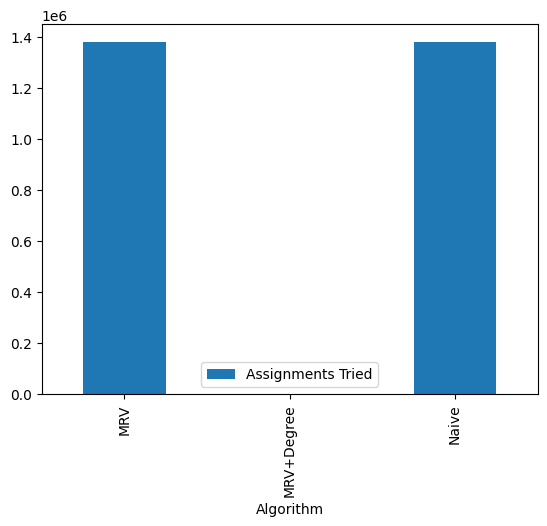

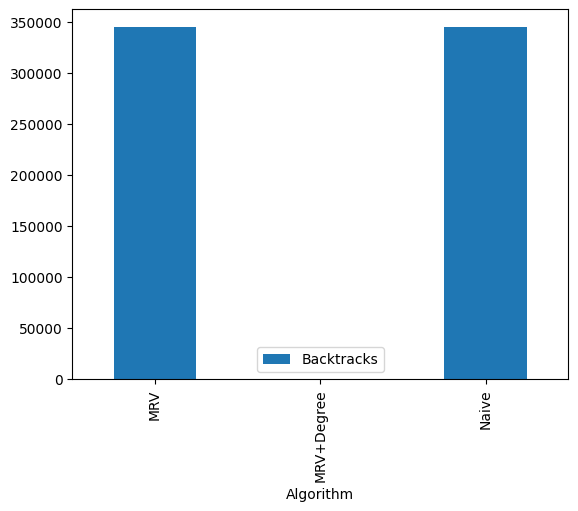

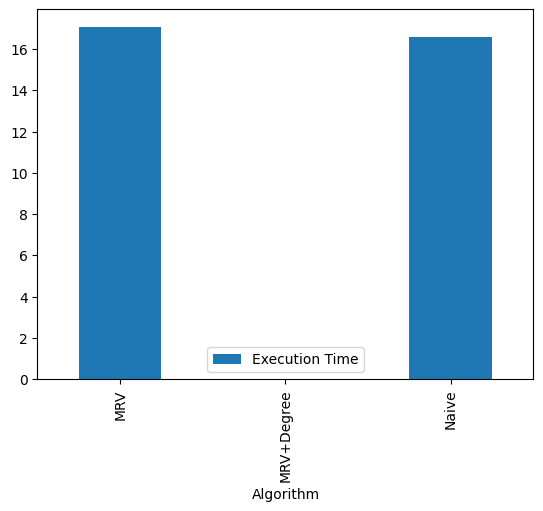

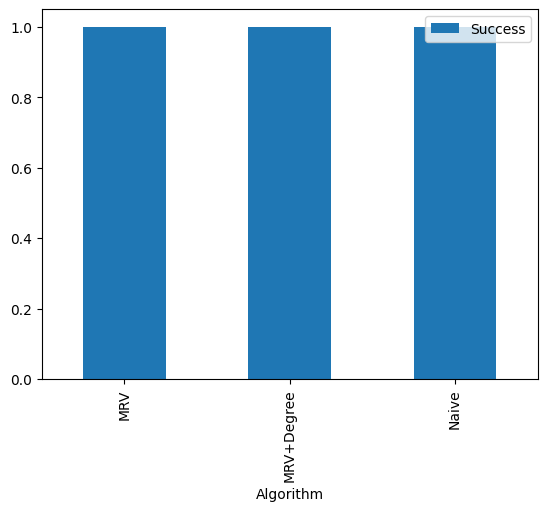

In [35]:
benchmark_summary.plot(
    x="Algorithm",
    y="Nodes Visited",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Assignments Tried",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Backtracks",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Execution Time",
    kind="bar"
)

benchmark_summary.plot(
    x="Algorithm",
    y="Success",
    kind="bar"
)

<h3> Constraint Density </h3>

In [38]:
densities = [
    0.05,
    0.2,
    0.4,
]

In [ ]:
num_trials = 3

density_results = []

for density in densities:
    for trial in range(num_trials):
        problem = generate_graph_coloring_csp(
            num_variables=30,
            num_colors=4,
            edge_probability=density,
        )

        for name, solver in solvers:
            result = run_solver_experiment(
                problem,
                solver,
            )

            result["Algorithm"] = name
            result["Constraint Density"] = density
            result["Trial"] = trial

            density_results.append(
                result
            )

In [ ]:
density_df = pd.DataFrame(
    density_results
)

density_df

In [ ]:
density_summary = (
    density_df
    .groupby(
        [
            "Constraint Density",
            "Algorithm",
        ]
    )
    [
        [
            "Nodes Visited",
            "Assignments Tried",
            "Backtracks",
            "Execution Time",
            "Success",
        ]
    ]
    .mean()
    .reset_index()
)

In [ ]:
for algorithm in density_summary["Algorithm"].unique():
    subset = density_summary[
        density_summary["Algorithm"] == algorithm
    ]
    plt.plot(
        subset["Constraint Density"],
        subset["Nodes Visited"],
        marker="o",
        label=algorithm,
    )

plt.xlabel(
    "Constraint Density"
)
plt.ylabel(
    "Nodes Visited"
)
plt.legend()
plt.title(
    "Effect of Constraint Density on Search"
)
plt.show()

<h1> Forward Checking </h1>